<a href="https://colab.research.google.com/github/PHANNhatTien/TCAD-training/blob/main/examples/plotting/visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualizing DEVSIM results in a Jupyter Notebook

Excellent standalone software exist to visualize meshes on results such as [VisIt](https://visit-dav.github.io/visit-website/index.html) and [Paraview](https://www.paraview.org/).

However, it is sometimes useful to interweave code and visualization, for instance when debugging.

There are many ways to do this. Here, we use [PyVista](https://docs.pyvista.org/) with the [panel](https://panel.holoviz.org/) backend.

### Installing PyVista

You will need to install the requisite packages:

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
install_pyvista = True # True to install
package_manager = 'pip' # or 'pip'

if install_pyvista:
    if package_manager=='conda':
        %conda install --yes -c conda-forge pyvista
        %conda install --yes -c conda-forge panel
        %conda install -c conda-forge wurlitzer
    elif package_manager=='pip':
        %pip install pyvista
        %pip install panel
        %pip install wurlitzer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.0/146.0 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 19.1 MB/s eta 0:00:00


In [3]:
# Install devsim, required by the gmsh scripts
!pip install devsim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 10.6 MB/s eta 0:00:00


### Generating mesh data

A DEVSIM simulation's mesh data can be saved to a `.dat` file with the [devsim.write_devices](https://devsim.net/CommandReference.html#devsim.write_devices) function with the `type='tecplot'` argument.

In this examples directory, the `gmsh_diode2d.py` and `gmsh_diode3d.py` scripts can perform this and generate, respectively, `gmsh_diode2d.dat` and `gmsh_diode3d_dd.dat`.

In [4]:
import os

# Define the base directory where your scripts are located.
# You may need to change this path to your actual script location, e.g., in your Google Drive.
base_dir = '/content/drive/MyDrive/DEVSIM/devsim-main/examples/diode' # <--- IMPORTANT: Change this path!

run = True # True to run the scripts

if run:
    # Store the original working directory
    original_cwd = os.getcwd()
    # Change the working directory to where the scripts are located
    os.chdir(base_dir)
    try:
        !python gmsh_diode2d.py
        !python gmsh_diode3d.py
    finally:
        # Change back to the original working directory
        os.chdir(original_cwd)

Physical group name Base has 0 Tetrahedra.
Physical group name Base has 0 Triangles.
Physical group name Base has 19 Lines.
Physical group name Base has 20 Points.
Physical group name Bulk has 0 Tetrahedra.
Physical group name Bulk has 922 Triangles.
Physical group name Bulk has 1422 Lines.
Physical group name Bulk has 501 Points.
Physical group name Emitter has 0 Tetrahedra.
Physical group name Emitter has 0 Triangles.
Physical group name Emitter has 20 Lines.
Physical group name Emitter has 21 Points.
Device diode2d has 501 coordinates with max index 501
Region Bulk has 501 nodes.
Contact bot in region Bulk with 21 nodes
Contact top in region Bulk with 20 nodes
number of equations 501
Iteration: 0
  Device: "diode2d"	RelError: 1.00000e+00	AbsError: 8.93836e-02
    Region: "Bulk"	RelError: 1.00000e+00	AbsError: 8.93836e-02
      Equation: "PotentialEquation"	RelError: 1.00000e+00	AbsError: 8.93836e-02
Iteration: 1
  Device: "diode2d"	RelError: 4.91460e-01	AbsError: 8.63816e-02
    Reg

### 2D Visualization

We can load the `.dat` data and visualize it in the notebook. Specifically, we will load the `xy` plane, and display the "Electrons" field:

In [5]:
import pyvista as pv
from wurlitzer import pipes # To suppress some vtk output

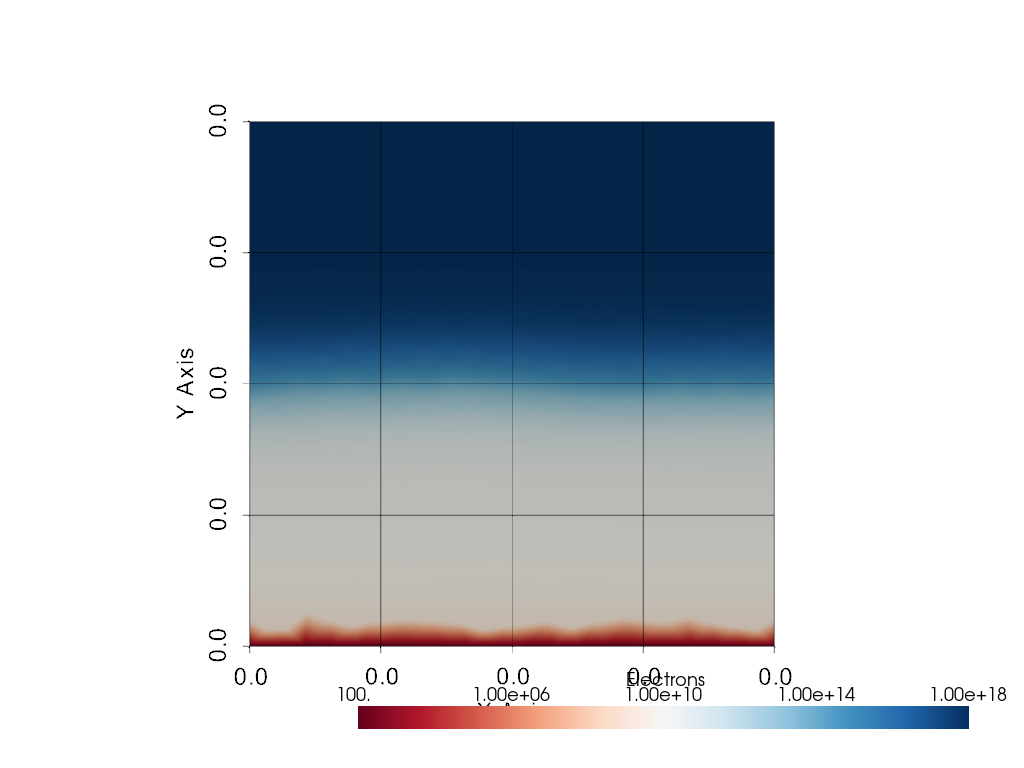

In [6]:
import os

with pipes() as (out, err):
    reader = pv.get_reader(os.path.join(base_dir, 'gmsh_diode2d.dat'))
    mesh = reader.read()
    plotter = pv.Plotter(notebook=True)
    _ = plotter.add_mesh(mesh, scalars='Electrons', log_scale=True, cmap='RdBu')
    _ = plotter.show_grid()
    _ = plotter.camera_position = "xy"
    _ = plotter.show(jupyter_backend='panel')

### Visualizing Mesh Triangles

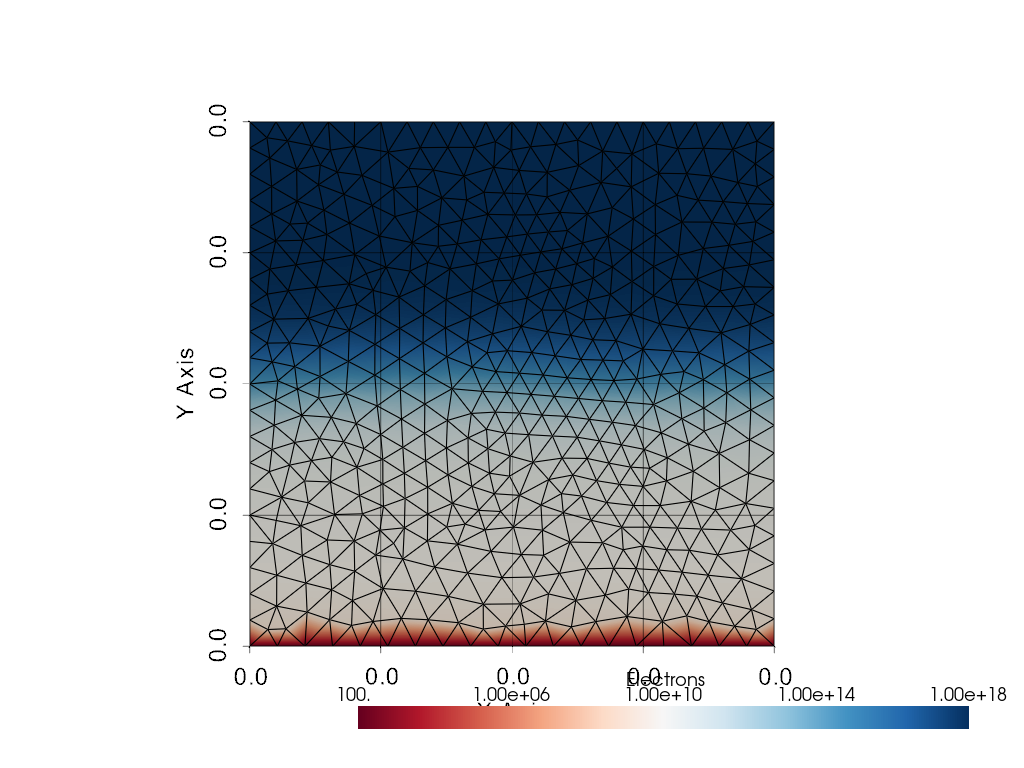

In [7]:
# Ensure pyvista and its dependencies are installed
!pip install pyvista panel wurlitzer

import os
import pyvista as pv
from wurlitzer import pipes

with pipes() as (out, err):
    reader = pv.get_reader(os.path.join(base_dir, 'gmsh_diode2d.dat'))
    mesh = reader.read()
    plotter = pv.Plotter(notebook=True)
    # Add the mesh with show_edges=True to visualize the triangles
    _ = plotter.add_mesh(mesh, show_edges=True, scalars='Electrons', log_scale=True, cmap='RdBu')
    _ = plotter.show_grid()
    _ = plotter.camera_position = "xy"
    _ = plotter.show(jupyter_backend='panel')

### 3D Visualization

In 3D, we choose the `panel` backend for interactive visualization:

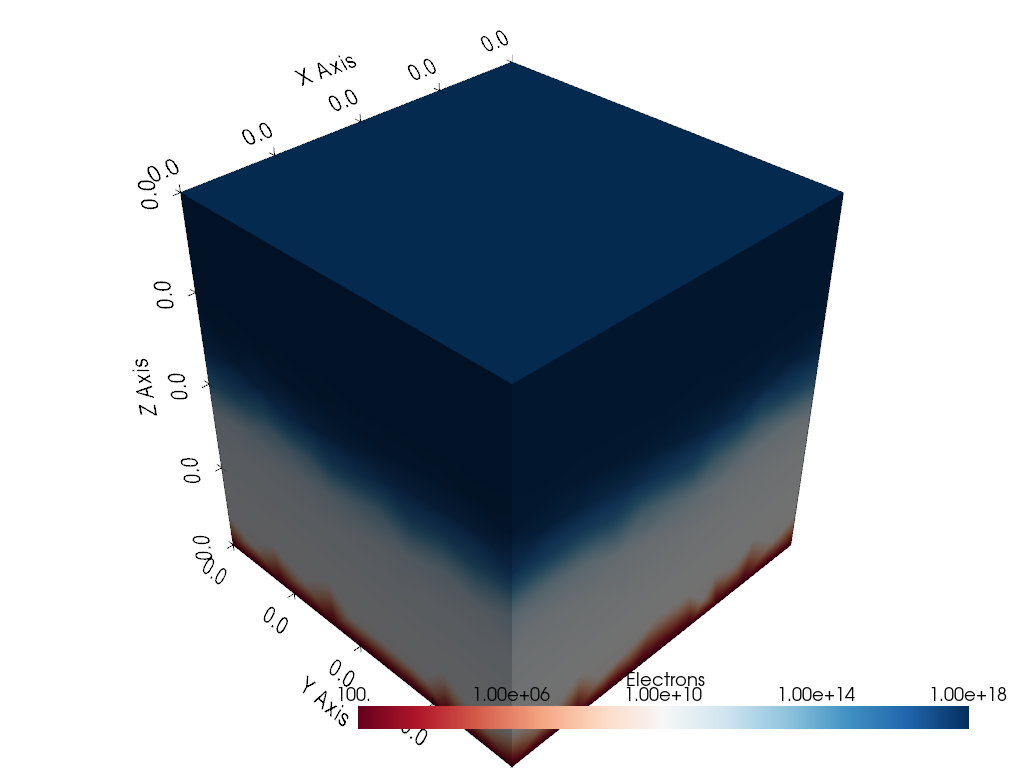

In [8]:
import os

with pipes() as (out, err):
    reader = pv.get_reader(os.path.join(base_dir, 'gmsh_diode3d_dd.dat'))
    mesh = reader.read()
    plotter = pv.Plotter(notebook=True)
    _ = plotter.add_mesh(mesh, scalars='Electrons', log_scale=True, cmap='RdBu')
    _ = plotter.show_grid()
    _ = plotter.show(jupyter_backend='panel')

### Going further

There are many more plotting options and examples in the [pyvista examples](https://docs.pyvista.org/examples/index.html).

In [37]:
import devsim # Import the devsim module
# Building the 2d planar MOSFET structure
#
# Design scenario:  Bulk Si -> STI -> PWELL -> NWELL -> Dummygate -> Halo -> SiN spacer -> SDE -> Epi SiGe S/D PMOS -> S/D NMOS -> CESL
#

# Explicitly import helper functions from simple_physics to be used without the devsim prefix
from devsim import add_2d_contact, contact_node_model

device = "CMOS_Device"

# Delete mesh if it already exists to allow re-running the cell
if device in devsim.get_mesh_list():
    devsim.delete_mesh(mesh=device)

# Define the mesh grid coordinates
devsim.create_2d_mesh(mesh=device)
devsim.add_2d_mesh_line(mesh=device, dir="x", pos=0.0, ps=0.01)
devsim.add_2d_mesh_line(mesh=device, dir="x", pos=1.0, ps=0.1)
devsim.add_2d_mesh_line(mesh=device, dir="y", pos=-0.5, ps=0.1)
devsim.add_2d_mesh_line(mesh=device, dir="y", pos=0.5, ps=0.1)

# Bulk Silicon & Wells
devsim.add_2d_region(mesh=device, material="Silicon", region="PWELL", xl=0, xh=1, yl=-0.5, yh=0)
devsim.add_2d_region(mesh=device, material="Silicon", region="NWELL", xl=0, xh=1, yl=0, yh=0.5)

# Shallow Trench Isolation (STI)
devsim.add_2d_region(mesh=device, material="Oxide", region="STI", xl=0, xh=0.3, yl=-0.1, yh=0.1)

# Dummy Gate & Spacers
devsim.add_2d_region(mesh=device, material="Polysilicon", region="Gate", xl=-0.1, xh=0, yl=-0.05, yh=0.05)
devsim.add_2d_region(mesh=device, material="Nitride", region="SiN_Spacer", xl=-0.1, xh=0, yl=0.05, yh=0.1)

# epi SiGe S/D PMOS (defined as a unique region for different physics)
devsim.add_2d_region(mesh=device, material="Silicon", region="PMOS_SD", xl=0, xh=0.1, yl=0.1, yh=0.4)

# Add contacts to the device (MOVED BEFORE finalize_mesh)
devsim.add_2d_contact(mesh=device, name="gate_contact", region="Gate", material="Polysilicon", xl=-0.1, xh=0, yl=-0.05, yh=0.05)
devsim.add_2d_contact(mesh=device, name="PWELL_Source", region="PWELL", material="Silicon", xl=0, xh=0.05, yl=-0.5, yh=-0.45) # Example source contact
devsim.add_2d_contact(mesh=device, name="PWELL_Drain", region="PWELL", material="Silicon", xl=0.95, xh=1, yl=-0.5, yh=-0.45) # Example drain contact

devsim.finalize_mesh(mesh=device)

# Delete device if it already exists to allow re-running the cell
if device in devsim.get_device_list():
    devsim.delete_device(device=device)

devsim.create_device(mesh=device, device=device)

# Add electrical contacts to the device and set their circuit nodes
add_2d_contact(device=device, name="gate_contact", region="Gate", material="Polysilicon")
add_2d_contact(device=device, name="PWELL_Source", region="PWELL", material="Silicon")
add_2d_contact(device=device, name="PWELL_Drain", region="PWELL", material="Silicon")

# Set initial contact voltages (boundary conditions for Potential)
# For an initial equilibrium solve, setting all to 0V is common.
devsim.set_parameter(device=device, name="gate_contact_bias", value=0.0)
devsim.set_parameter(device=device, name="PWELL_Source_bias", value=0.0)
devsim.set_parameter(device=device, name="PWELL_Drain_bias", value=0.0)

# Apply these contact voltages to the Potential solution variable
contact_node_model(device=device, contact="gate_contact", name="Potential", equation="gate_contact_bias")
contact_node_model(device=device, contact="PWELL_Source", name="Potential", equation="PWELL_Source_bias")
contact_node_model(device=device, contact="PWELL_Drain", name="Potential", equation="PWELL_Drain_bias")

# Define doping for Wells and Source/Drain extensions (SDE/Halo)
devsim.node_model(device=device, region="PWELL", name="Acceptors", equation="1e17")
devsim.node_model(device=device, region="NWELL", name="Donors", equation="1e17")

# Example SDE/Halo model using a step or Gaussian-like function
devsim.node_model(device=device, region="PWELL", name="NetDoping",
                  equation="1e20*step(0.1-x)*step(y+0.1) - Acceptors")

# epi SiGe physical adjustments (Bandgap Narrowing due to Germanium)
# Note: Physical constants are set as parameters [8]
devsim.set_parameter(device=device, region="PMOS_SD", name="BandGap", value=1.0) # Lower BG for SiGe

# Create solution variable
devsim.node_solution(device=device, region="PWELL", name="Potential")

# Define Edge models for Potential Gradient
devsim.edge_from_node_model(device=device, region="PWELL", node_model="Potential")
devsim.edge_model(device=device, region="PWELL", name="ElectricField",
                  equation="(Potential@n0 - Potential@n1)*EdgeInverseLength")

# Displacement field (D = epsilon * E)
devsim.set_parameter(device=device, region="PWELL", name="Permittivity", value=11.7 * 8.85e-14)
devsim.edge_model(device=device, region="PWELL", name="DField", equation="Permittivity*ElectricField")

# Finalize the equation
devsim.equation(device=device, region="PWELL", name="PotentialEquation",
                variable_name="Potential", edge_model="DField", variable_update="default")

# Solve
devsim.solve(type="dc", absolute_error=1.0, relative_error=1e-10)

Creating Region PWELL
Creating Region STI
Creating Region PMOS_SD
Creating Region NWELL
There should be at least 2 contacts on the device and there are only 0
Adding 126 nodes
Adding 314 edges with 253 duplicates removed
Adding 189 triangles  with 0 duplicate removed
Adding 32 nodes
Adding 73 edges with 53 duplicates removed
Adding 42 triangles  with 0 duplicate removed
Adding 148 nodes
Adding 378 edges with 315 duplicates removed
Adding 231 triangles  with 0 duplicate removed
Adding 47 nodes
Adding 104 edges with 70 duplicates removed
Adding 58 triangles  with 0 duplicate removed


error: device is an invalid option
